# Statistical analysis of the data

This notebook consists of statistical checks of the inspected variables, related to the hypothesis set for this part of analysis: 

RQ: How do selected manifestations of political identity (political parties, party status, political orientation) shape parliamentary discourse in terms of sentiment?

- H1. Coalition parties will consistently exhibit higher neutral/positive sentiment, while opposition parties will display more negativity, though intensity may vary across terms based on political events.
- H2: Changes in political orientation will correlate with sentiment shifts, with right/traditionalist parties showing higher negativity.
- H3: Negative sentiment will dominate parliamentary debates, with minor occurrences of other sentiment categories. Political crises, elections, or leadership changes will correlate with sentiment shifts.

The sample illustrates the workflow. The full analysis is run on the complete dataset for final results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats


In [2]:
#df = pd.read_csv("../Sample/Datasets/Sample_interpolated_values.tsv", sep="\t", encoding="utf-8") #Sample input
df = pd.read_csv("../Results/Datasets/ParlaMint_CHES_interpolated_values.tsv", sep="\t", encoding="utf-8") #Full dataset input

df = df[(df["Speaker_role"] != "Chairperson") & (df["Speaker_minister"] == "notMinister")& (df["Speaker_MP"] == "MP") & (df["Senti_3"] != "-") & (df["Speaker_party"] != "-")] 
#Remove chairperson (to not include procedural speeches), Minister and guest speakers, remove speeches without sentiment and speeches by MPs with no party.
df.head()
df.shape

(130633, 30)

## Checking the data distributions
In the first step we check the distributions of the sentiment and lrgen values in the dataset.

n === SENTI_N === 
Count non-missing data: 130633


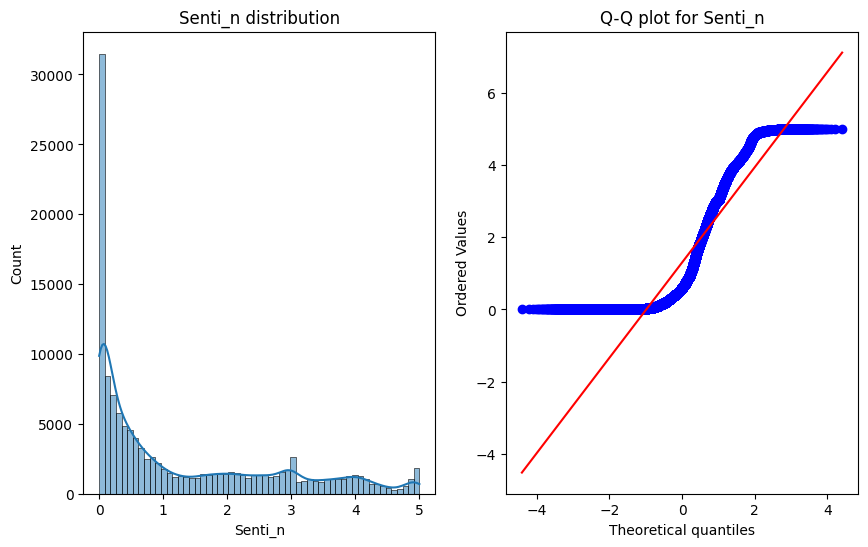

n === LRGEN === 
Count non-missing data: 125575


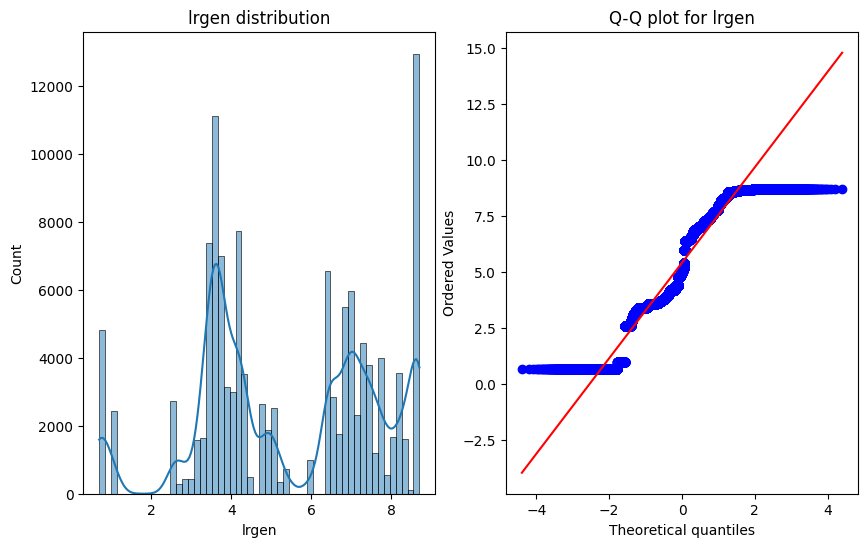

In [3]:
df.shape
cols=["Senti_n", "lrgen"]
for col in cols: 
    data = df[col].dropna()
    print(f"n === {col.upper()} === ")
    print(f"Count non-missing data: {len(data)}")

    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    sns.histplot(data, kde=True)
    plt.title(f"{col} distribution")

    plt.subplot(1,2,2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"Q-Q plot for {col}")
    plt.show()

## H1: Coalition parties more neutral/positive; opposition more negative

Given the non-normal distributions of sentiment checks, we will use Mann–Whitney U test to check several options: 

- a) is there a (statistically significant) difference between the two variables?
    - Null hypothesis (H₀): The distribution of sentiment scores is the same in coalition and opposition parties.

For this we will first run two-sided test (to compare if there is a difference between coalition and opposition in terms of sentiment).

- b) if the results are statistically significant, we will check the direction with the one-sided test


### Two-sided Mann–Whitney U (entire dataset)
As the dataset itself is quite large, which can influence the statistical tests, we will be aggregating the data into meaningful subsets (e.g. to test the coalition and oppostion test, we will first group the dataset by )

In [4]:
from scipy.stats import mannwhitneyu

#Remove speeches of speakers without party affiliation (and thus "-" for Party_status, and remove rows with missing sentiment values)
print(len(df))
df_status= df[df["Senti_n"].notna()]
print(df_status.shape)

#Check mean and median
status_mean = df_status.groupby(["Party_status"])["Senti_n"].mean()
status_median = df_status.groupby(["Party_status"])["Senti_n"].median()

print("Mean sentiment per Party status: \n", status_mean)
print("Median sentiment per Party status: \n", status_median)

130633
(130633, 30)
Mean sentiment per Party status: 
 Party_status
-             1.188134
Coalition     1.819109
Opposition    0.927008
Name: Senti_n, dtype: float64
Median sentiment per Party status: 
 Party_status
-             0.51
Coalition     1.49
Opposition    0.33
Name: Senti_n, dtype: float64


In [5]:
#Aggregate by Party + Party_status
party_scores = df_status.groupby(['Speaker_party', 'Party_status'])['Senti_n'].mean().reset_index()

coal_scores = party_scores[party_scores['Party_status'] == 'Coalition']['Senti_n']
oppo_scores = party_scores[party_scores['Party_status'] == 'Opposition']['Senti_n']

In [6]:
from itertools import product

u_stat, p_two = mannwhitneyu(coal_scores, oppo_scores, alternative="two-sided")
print("Mann–Whitney U statistic:", u_stat)
print("Two-sided p-value:", p_two)

n1, n2 = len(coal_scores), len(oppo_scores)
#effect_size_r = 1 - (2*u_stat) / (n1*n2)
favorable = sum(c > o for c, o in product(coal_scores, oppo_scores))
unfavorable = sum(c < o for c, o in product(coal_scores, oppo_scores))
r = (favorable - unfavorable) / (n1 * n2)
print("Effect size (rank-biserial r):", r)

print("Coalition median:", coal_scores.median())
print("Opposition median", oppo_scores.median())
print("Coalition mean:", coal_scores.mean())
print("Opposition mean", oppo_scores.mean())

Mann–Whitney U statistic: 225.0
Two-sided p-value: 0.001432908329205714
Effect size (rank-biserial r): 0.6544117647058824
Coalition median: 1.8237163375224414
Opposition median 1.0285983508546088
Coalition mean: 1.8805856929605371
Opposition mean 1.2373993493088875


Sentiment scores differs significantly between coalition and opposition parties (Mann–Whitney U = 225.0, p < 0.001). The median sentiment was higher for coalition parties, consistent with the hypothesis that coalition MPs speak in a more neutral/positive tone compared to opposition MPs. 

Given the statistically significant results in the two-sided test, we then test for direction with a one-sided test.

### One-sided Mann-Whitney U test


In [7]:
from itertools import product
u_stat, p_one = mannwhitneyu(coal_scores, oppo_scores, alternative='greater')

print("U:", u_stat, "One-sided p-value (coalition > opposition):", p_one)

# Rank-biserial effect size
favorable = sum(c > o for c, o in product(coal_scores, oppo_scores))
unfavorable = sum(c < o for c, o in product(coal_scores, oppo_scores))
r = (favorable - unfavorable) / (n1 * n2)

print("Effect size (rank-biserial r):", r)

U: 225.0 One-sided p-value (coalition > opposition): 0.000716454164602857
Effect size (rank-biserial r): 0.6544117647058824


The one-sided test cofirms that the direction is statistically significant (coalition > opposition). The Rank-biserial effect size also points out that the effect size (r=0.65) is quite substantial, signifying that this difference in sentiment distribution between coalition and opposition is relatively consistent pattern across the dataset (and that the different is not a result of only a few extremes).



## H2: Changes in political orientation will correlate with sentiment shifts, with right/traditionalist parties showing higher negativity.

The statistical checks for the H2 will consist of: 
- The Spearman r test will allow usto establish whether:
    - there is a monotonic relationship between lrgen and sentiment
    - what is the direction of the relationship (positive or negative)
    - the strength and statistical significance of the relationship  
- As the lrgen and galtan data have gaps, we interpolated the values to get values for the missing years, following the natural trends indetified within the data. 

The null hypothesis (H₀): There is no correlation between changes in political orientation and sentiment shifts; right/traditionalist parties do not show systematically higher negativity.

### LRGEN 


In [8]:
df_lrgen = df[["Senti_n", "lrgen"]].dropna()
print(df_lrgen.shape)

(125575, 2)


In [9]:
from scipy.stats import spearmanr

rho, p = spearmanr(df_lrgen["Senti_n"], df_lrgen["lrgen"])
print(f"Spearman correlation: {rho}, p-value:{p}")

Spearman correlation: -0.03335092353758284, p-value:3.019093851680613e-32


While the Spearman correlation shows that this difference (which is slightly negative in direction) is statistically significant, we have a large sample, which tends to influence the test (even small correlations can become significant). Therefore we repeat this test on aggregated dataset. Since lrgen is dependent on the party and year it was calculated for, we first aggregate the dataset to mean scores for individual party in a particular year.

In [10]:
party_lrgen = (
    df.groupby(['Speaker_party', 'Year'], as_index=False)
      .agg({'Senti_n': 'mean', 'lrgen': 'mean'})
)
party_lrgen
df_party_lrgen = party_lrgen[party_lrgen['Speaker_party'] != '-']
df_party_lrgen = df_party_lrgen.dropna(subset=["lrgen"])

df_party_lrgen

,Speaker_party,Year,Senti_n,lrgen
5,DeSUS,2000,2.423636,3.40
6,DeSUS,2001,2.262000,3.40
7,DeSUS,2002,1.912384,3.40
8,DeSUS,2003,2.119293,3.35
9,DeSUS,2004,2.510649,3.30
...,...,...,...,...
231,Zares,2007,0.837857,3.90
232,Zares,2008,0.860968,3.90
233,Zares,2009,1.430217,3.90
234,Zares,2010,1.578067,3.90


In [11]:
rho, p = spearmanr(df_party_lrgen["Senti_n"], df_party_lrgen["lrgen"])
print(f"Spearman correlation: {rho}, p-value:{p}")

Spearman correlation: -0.05460959202593012, p-value:0.466550028413096


The ρ shows very weak (or, almost no) monotonic relationship, and p shows that this correlation is not statistically significant, which indicates no evidence that changes in lrgen are associated with changes in sentiment. This is further supported in plots, comparing trends in lrgen/sentiment for individual party. 

## GALTAN

In [12]:
df_galtan = df[["Senti_n", "galtan"]].dropna()
print(df_galtan.shape)

(125575, 2)


In [13]:
rho, p = spearmanr(df_galtan["Senti_n"], df_galtan["galtan"])
print(f"Spearman correlation: {rho}, p-value:{p}")

Spearman correlation: -0.013664056798548084, p-value:1.2837714473065738e-06


In [14]:
party_galtan = (
    df.groupby(['Speaker_party', 'Year'], as_index=False)
      .agg({'Senti_n': 'mean', 'galtan': 'mean'})
)
party_galtan
df_party_galtan = party_galtan[party_galtan['Speaker_party'] != '-']
df_party_galtan = df_party_galtan.dropna(subset=["galtan"])

df_party_galtan

,Speaker_party,Year,Senti_n,galtan
5,DeSUS,2000,2.423636,5.80
6,DeSUS,2001,2.262000,5.80
7,DeSUS,2002,1.912384,5.80
8,DeSUS,2003,2.119293,5.47
9,DeSUS,2004,2.510649,5.15
...,...,...,...,...
231,Zares,2007,0.837857,1.80
232,Zares,2008,0.860968,1.80
233,Zares,2009,1.430217,1.80
234,Zares,2010,1.578067,1.80


In [15]:
rho, p = spearmanr(df_party_galtan["Senti_n"], df_party_galtan["galtan"])
print(f"Spearman correlation: {rho}, p-value:{p}")

Spearman correlation: 0.06333449054035152, p-value:0.3983062982724257


Similar observations than for LRGEN: 
- Any observed statistical significance is likely driven primarily by the large sample size rather than a meaningful effect.
- On an aggregated level, there is no (or almost no) monotonic relationship between political orientation and sentiment.
- This conclusion is supported by visualizations of sentiment against party orientation (Galtan relationship).
The null hypothesis cannot be rejected.